# Task 1: Term Deposit Subscription Prediction

## Objective
The objective of this project is to predict whether a bank customer will subscribe to a term deposit after a marketing campaign.

This is a binary classification problem where the target variable is `y`.

- `yes`: customer subscribed
- `no`: customer did not subscribe

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_auc_score, roc_curve

import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../images', exist_ok=True)

In [2]:
df = pd.read_csv('../data/bank-additional-full.csv', sep=';')

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Dataset Overview

The dataset contains customer information, previous campaign details, economic indicators, and the final subscription result.  
The target column is `y`.

In [3]:
print("Shape:", df.shape)
df.info()

Shape: (41188, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.id

In [4]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [5]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

## Exploratory Data Analysis

EDA was performed to understand the distribution of the target variable, customer demographics, campaign-related features, and hidden missing values.

In [6]:
df['y'].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

In [7]:
df['y'].value_counts(normalize=True) * 100

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

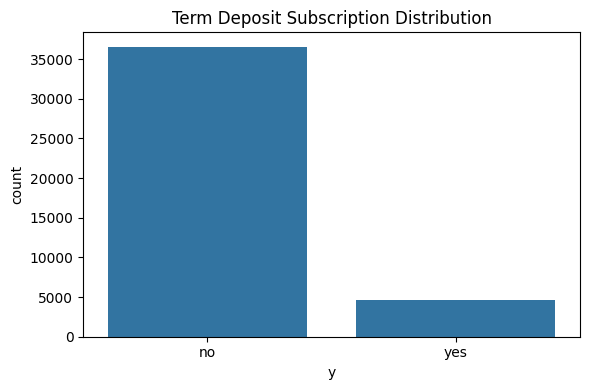

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='y', data=df)
plt.title('Term Deposit Subscription Distribution')
plt.tight_layout()
plt.savefig('../images/target_distribution.png')
plt.show()

The target variable is highly imbalanced. Most customers did not subscribe to the term deposit.  
Because of this imbalance, accuracy alone is not enough, so F1-score, confusion matrix, and ROC-AUC are used for evaluation.

In [9]:
unknown_counts = {}

for col in df.columns:
    if df[col].dtype == 'object':
        unknown_counts[col] = (df[col] == 'unknown').sum()

pd.DataFrame.from_dict(unknown_counts, orient='index', columns=['unknown_count'])

,unknown_count
job,330
marital,80
education,1731
default,8597
housing,990
loan,990
contact,0
month,0
day_of_week,0
poutcome,0


Some categorical columns contain `unknown` values. These were kept as a separate category instead of removing rows, because unknown information may still carry useful behavioral patterns.

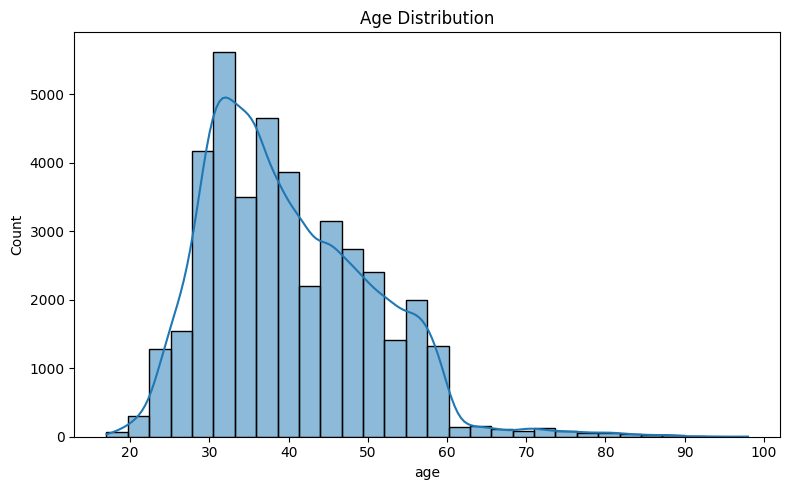

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.tight_layout()
plt.savefig('../images/age_distribution.png')
plt.show()

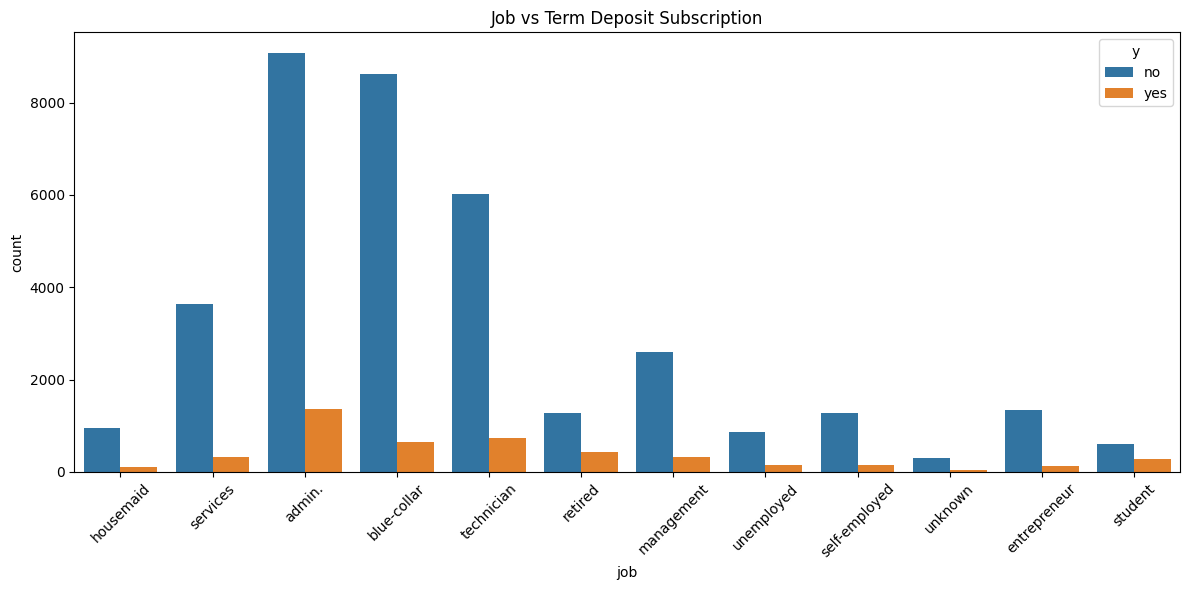

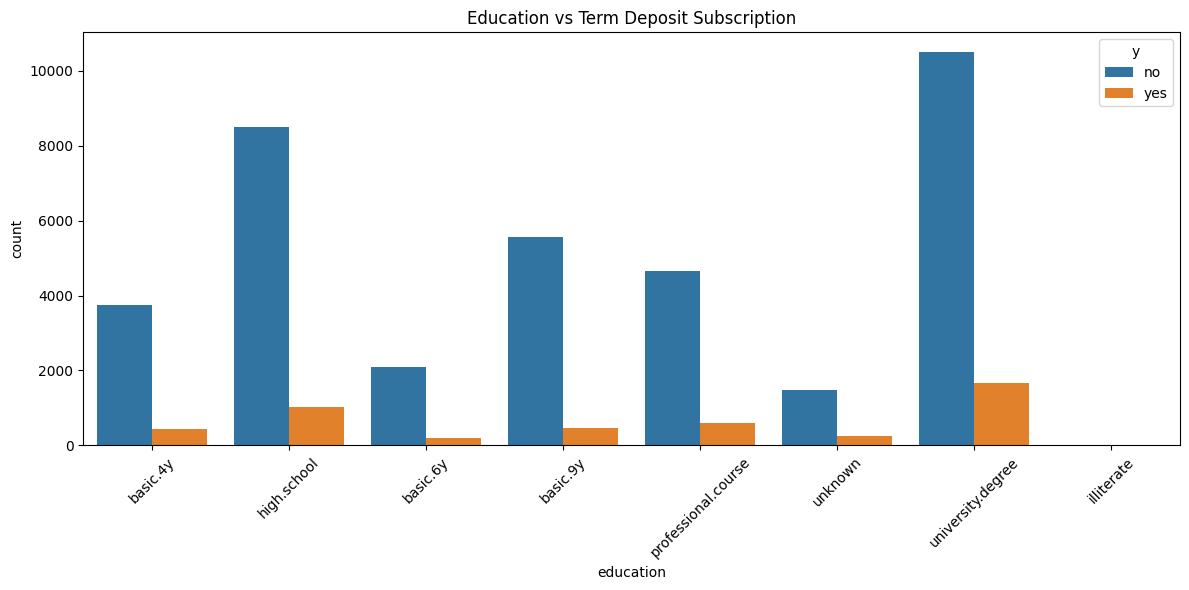

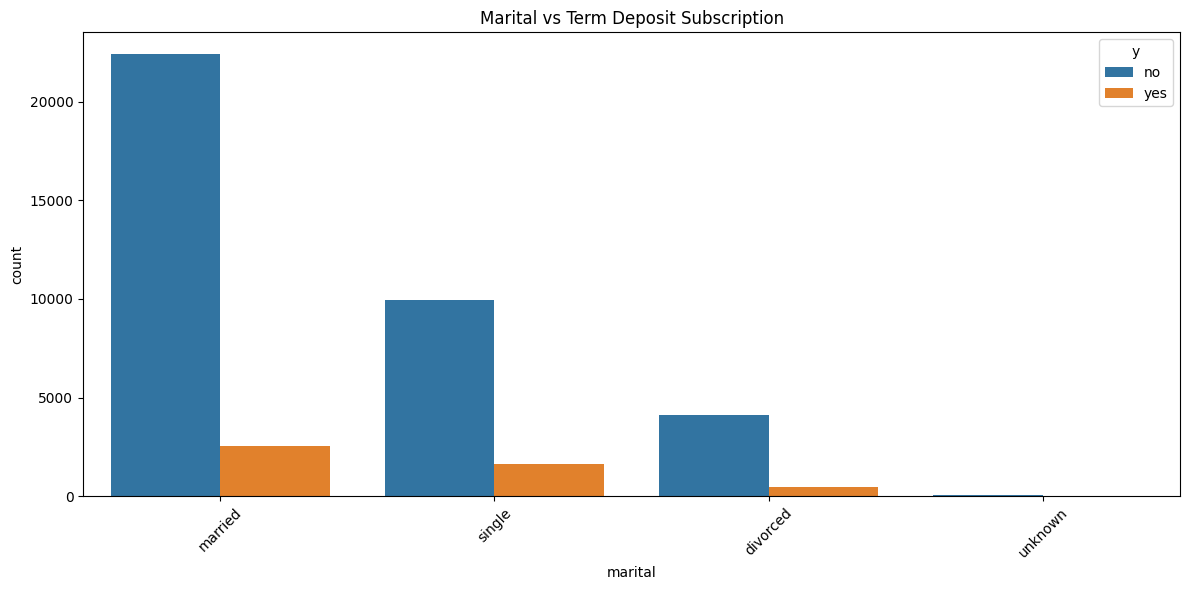

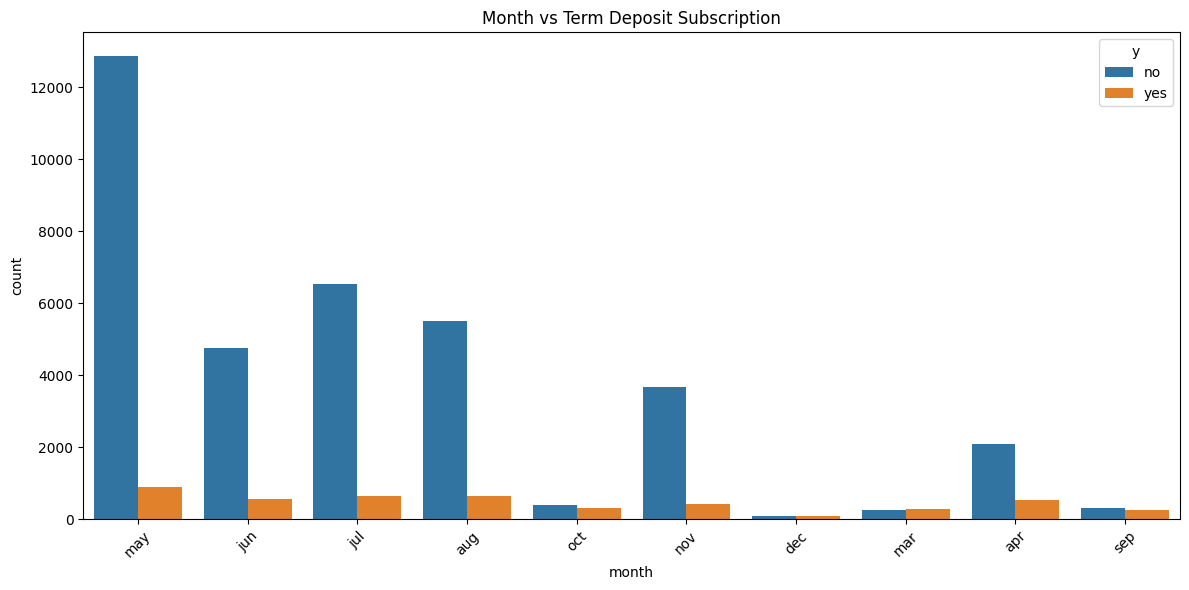

In [11]:
features = ['job', 'education', 'marital', 'month']

for feature in features:
    plt.figure(figsize=(12,6))
    sns.countplot(x=feature, hue='y', data=df)
    plt.title(f'{feature.capitalize()} vs Term Deposit Subscription')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'../images/{feature}_vs_subscription.png')
    plt.show()

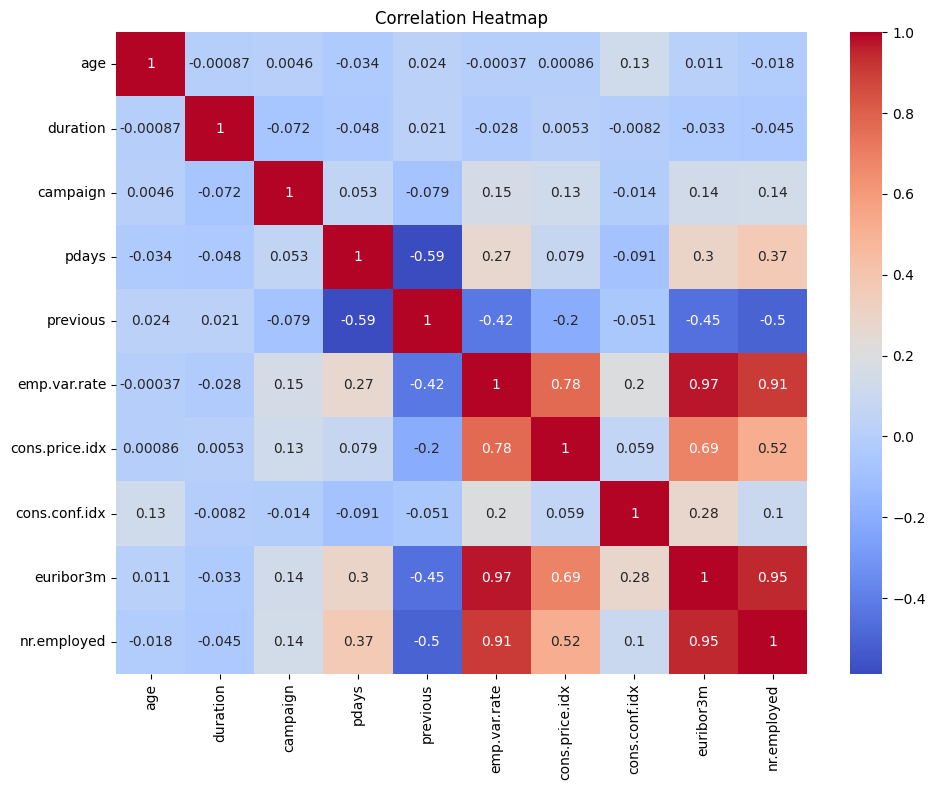

In [12]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png')
plt.show()

## Key EDA Findings

- The dataset is imbalanced, with very few customers subscribing compared to non-subscribers.
- Most customers are between 30 and 50 years old.
- The age distribution is slightly right-skewed because of older customers.
- Some columns contain hidden missing values represented as `unknown`.
- The value `999` in `pdays` indicates that many customers were not previously contacted.
- Job, education, marital status, and month show visible differences in subscription behavior.

## Data Preprocessing

Before model training, categorical variables were encoded using One-Hot Encoding.  
Numerical variables were scaled for Logistic Regression.  
The target variable was converted into binary format:

- yes = 1
- no = 0

In [13]:
df_model = df.copy()

df_model['y'] = df_model['y'].map({'yes': 1, 'no': 0})

X = df_model.drop('y', axis=1)
y = df_model['y']

categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print("Categorical columns:", list(categorical_cols))
print("Numerical columns:", list(numerical_cols))

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numerical columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (32950, 20)
Testing data: (8238, 20)


In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

## Model Building

Two classification models were trained:

1. Logistic Regression
2. Random Forest Classifier

In [16]:
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [17]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## Model Evaluation

The models were evaluated using:

- Confusion Matrix
- Classification Report
- F1-Score
- ROC-AUC Score
- ROC Curve

In [18]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"===== {model_name} =====")
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f'../images/{model_name.lower().replace(" ", "_")}_confusion_matrix.png')
    plt.show()
    
    return y_prob

===== Logistic Regression =====
F1 Score: 0.6036389582590082
ROC-AUC Score: 0.94383800533044

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.86      0.92      7310
           1       0.45      0.91      0.60       928

    accuracy                           0.87      8238
   macro avg       0.72      0.89      0.76      8238
weighted avg       0.93      0.87      0.88      8238



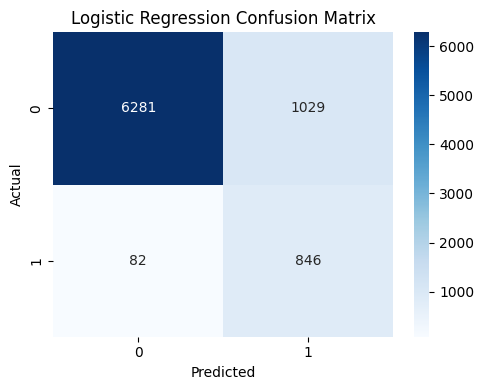

In [19]:
logistic_probs = evaluate_model(logistic_model, X_test, y_test, "Logistic Regression")

===== Random Forest =====
F1 Score: 0.5363881401617251
ROC-AUC Score: 0.947865612764753

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.95      7310
           1       0.72      0.43      0.54       928

    accuracy                           0.92      8238
   macro avg       0.82      0.70      0.75      8238
weighted avg       0.91      0.92      0.91      8238



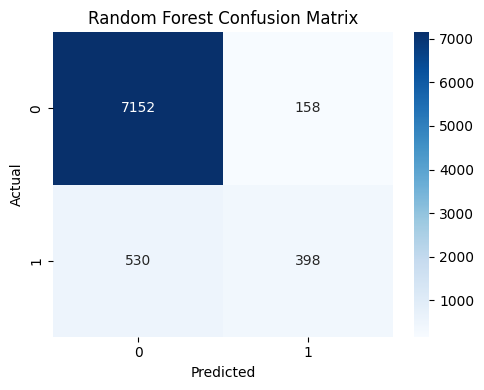

In [20]:
rf_probs = evaluate_model(rf_model, X_test, y_test, "Random Forest")

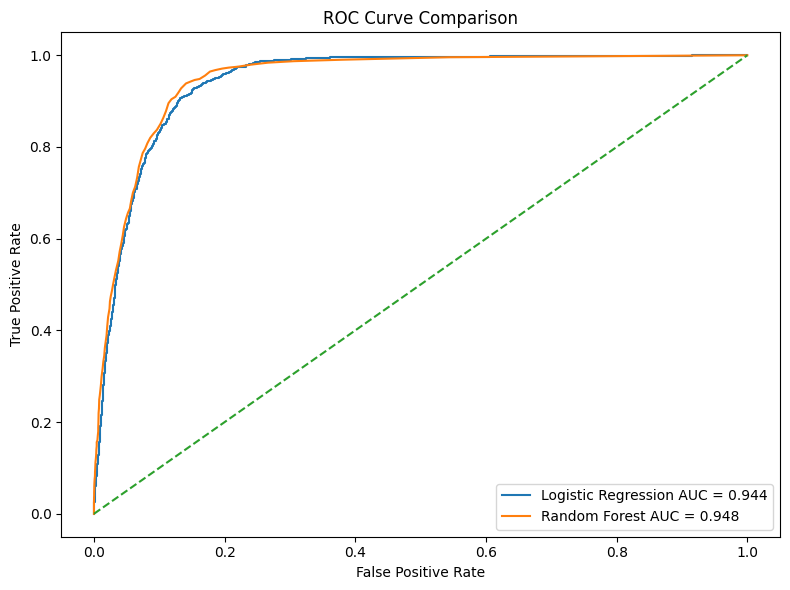

In [21]:
plt.figure(figsize=(8,6))

for probs, name in [(logistic_probs, 'Logistic Regression'), (rf_probs, 'Random Forest')]:
    fpr, tpr, thresholds = roc_curve(y_test, probs)
    auc_score = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} AUC = {auc_score:.3f}')

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('../images/roc_curve_comparison.png')
plt.show()

## Explainable AI Using SHAP

SHAP was used to explain individual predictions from the Random Forest model.  
This helps understand which features pushed the model toward predicting subscription or non-subscription.

In [ ]:
!pip install shap -q


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import shap

# Transform data using the preprocessing pipeline
X_train_transformed = rf_model.named_steps['preprocessor'].transform(X_train)
X_test_transformed = rf_model.named_steps['preprocessor'].transform(X_test)

# Get feature names
cat_features = rf_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_features = list(numerical_cols) + list(cat_features)

# Convert to dense if sparse
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

rf_classifier = rf_model.named_steps['classifier']

explainer = shap.TreeExplainer(rf_classifier)

sample_data = X_test_transformed[:5]
shap_values = explainer.shap_values(sample_data)

In [24]:
for i in range(5):
    print(f"Prediction {i+1}")
    print("Actual:", y_test.iloc[i])
    print("Predicted:", rf_model.predict(X_test.iloc[[i]])[0])
    print("Prediction Probability:", rf_model.predict_proba(X_test.iloc[[i]])[0][1])
    print("-" * 50)

Prediction 1
Actual: 0
Predicted: 0
Prediction Probability: 0.0
--------------------------------------------------
Prediction 2
Actual: 0
Predicted: 0
Prediction Probability: 0.1
--------------------------------------------------
Prediction 3
Actual: 0
Predicted: 0
Prediction Probability: 0.27
--------------------------------------------------
Prediction 4
Actual: 0
Predicted: 0
Prediction Probability: 0.0
--------------------------------------------------
Prediction 5
Actual: 0
Predicted: 0
Prediction Probability: 0.42
--------------------------------------------------


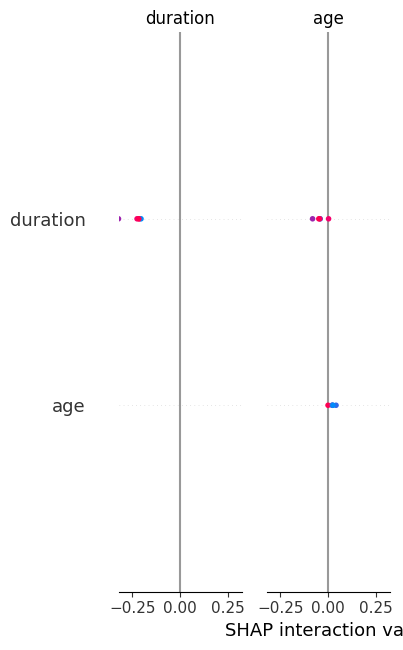

In [25]:
# SHAP summary plot for first 5 predictions
shap.summary_plot(
    shap_values[1] if isinstance(shap_values, list) else shap_values,
    sample_data,
    feature_names=all_features,
    show=False
)

plt.tight_layout()
plt.savefig('../images/shap_summary_first_5_predictions.png')
plt.show()

## Final Conclusion

This project built a machine learning classification system to predict whether a bank customer would subscribe to a term deposit.

The dataset was imbalanced, so evaluation focused on F1-score, confusion matrix, and ROC-AUC instead of accuracy alone.  
Categorical features were encoded using One-Hot Encoding, and two models were trained: Logistic Regression and Random Forest.

The Random Forest model captured non-linear relationships better, while Logistic Regression provided a simpler baseline.  
SHAP was used to explain five predictions, making the model more interpretable and useful for business decision-making.

From a business perspective, this type of model can help banks target customers more effectively and reduce unnecessary marketing calls.